In [ ]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = kagglehub.dataset_download("suraj520/rf-signal-data")
csv_path = os.path.join(path, "logged_data.csv")

df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'rf-signal-data' dataset.


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df = df.sort_values(by='Timestamp')
df = df.reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("\nColumns and Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (164160, 27)

Columns and Data Types:
Timestamp            datetime64[ns]
Frequency                     int64
Signal Strength               int64
Modulation                   object
Bandwidth                     int64
Location                     object
Device Type                  object
Antenna Type                 object
Temperature                   int64
Humidity                      int64
Wind Speed                    int64
Precipitation               float64
Weather Condition            object
Interference Type            object
Battery Level               float64
Power Source                   bool
CPU Usage                   float64
Memory Usage                float64
WiFi Strength                 int64
Disk Usage                  float64
System Load                 float64
Latitude                    float64
Longitude                   float64
Altitude(m)                 float64
Air Pressure                float64
Device Status                object
I/Q Data   

In [ ]:
# (Assuming 'df' is still loaded from the previous step)

# --- 1. HANDLE MISSING VALUES ---
# We assume missing interference means 'None' (Clean data)
df['Interference Type'] = df['Interference Type'].fillna('None')

# Drop 'Air Pressure' as it is empty
df = df.drop(columns=['Air Pressure'])

# Drop the single rows with missing values (clean up the edges)
df = df.dropna(subset=['Signal Strength', 'Temperature'])

# --- 2. FILTER FOR SINGLE FREQUENCY ---
# Find the most common frequency in the dataset
top_frequency = df['Frequency'].mode()[0]
print(f"Filtering dataset for the most common frequency: {top_frequency/1e6} MHz")

# Create a new dataframe 'df_signal' containing only this frequency
df_signal = df[df['Frequency'] == top_frequency].copy()

# Sort strictly by time again just to be safe
df_signal = df_signal.sort_values('Timestamp')

Filtering dataset for the most common frequency: 160.0 MHz


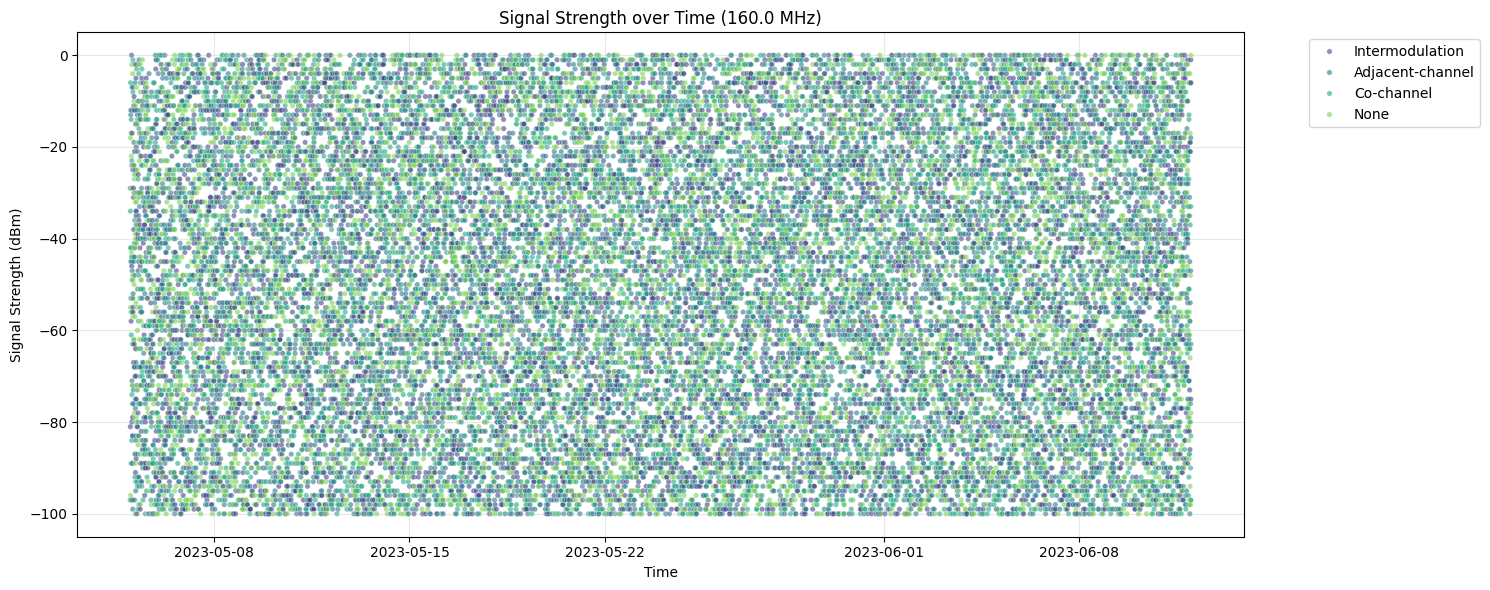


Interference Count (for Weights):
Interference Type
None                6959
Co-channel          6907
Intermodulation     6860
Adjacent-channel    6816
Name: count, dtype: int64


In [ ]:
# --- 3. VISUALIZATION (EDA) ---
plt.figure(figsize=(15, 6))

# Map Interference Types to Colors for the plot
# This helps us see if the "Drops" in signal match the "Interference" labels
sns.scatterplot(
    data=df_signal,
    x='Timestamp',
    y='Signal Strength',
    hue='Interference Type', # Color by interference
    s=15,
    alpha=0.6,
    palette='viridis' # Good for distinguishing categories
)

plt.title(f"Signal Strength over Time ({top_frequency/1e6} MHz)")
plt.ylabel("Signal Strength (dBm)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the breakdown of Interference Types for our weights later
print("\nInterference Count (for Weights):")
print(df_signal['Interference Type'].value_counts())

In [ ]:
df.head()

,Timestamp,Frequency,Signal Strength,Modulation,Bandwidth,Location,Device Type,Antenna Type,Temperature,Humidity,...,CPU Usage,Memory Usage,WiFi Strength,Disk Usage,System Load,Latitude,Longitude,Altitude(m),Device Status,I/Q Data
0,2023-05-05 00:00:00,120000000,-44,QAM,50000,"Patna, Bihar",HackRF,Yagi,24,47,...,25.0,28.3,-77,18.5,4.300781,25.612677,85.158875,59.46,Streaming I/Q data,"[(-0.7204492334669581-0.13150053996590505j), (..."
1,2023-05-05 00:00:20,160000000,-97,FM,1000000,"Patna, Bihar",HackRF,Yagi,27,39,...,0.0,28.3,-57,18.5,4.300781,25.612677,85.158875,59.46,Streaming I/Q data,"[(-0.9514742558373084-0.2713158600194827j), (-..."
2,2023-05-05 00:00:40,90000000,-87,BPSK,500000,"Patna, Bihar",Halow-U,Yagi,40,58,...,100.0,28.3,-20,18.5,4.300781,25.612677,85.158875,59.46,Transmitting beacon signal,"[(0.2227144792597957+0.958588241755097j), (0.2..."
3,2023-05-05 00:01:00,160000000,-29,FM,100000,"Patna, Bihar",Halow-U,Dipole,28,50,...,25.0,28.3,-38,18.5,4.300781,25.612677,85.158875,59.46,Transmitting beacon signal,"[(-0.3238055039162817+0.855187296295747j), (-0..."
4,2023-05-05 00:01:20,70000000,-26,8PSK,10000,"Patna, Bihar",HackRF,Omnidirectional,22,78,...,0.0,28.3,-43,18.5,4.300781,25.612677,85.158875,59.46,Streaming I/Q data,"[(-0.30500282741187124-0.26473341302686326j), ..."


In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline

# (Assuming 'df_signal' is loaded from the previous step)

# --- 1. DEFINE WEIGHTS (Feature Engineering) ---
def get_weight(interference_type):
    if interference_type == 'None':
        return 1.0
    elif interference_type == 'Adjacent-channel':
        return 0.5
    elif interference_type == 'Co-channel':
        return 0.1
    elif interference_type == 'Intermodulation':
        return 0.05 # Lowest trust
    else:
        return 1.0

# Apply the weights to a new column
df_signal['weights'] = df_signal['Interference Type'].apply(get_weight)

# --- 2. PREPARE DATA FOR SPLINE ---
# Splines require numeric X inputs. We convert Timestamps to "Seconds from start".
# This creates a continuous time axis.
start_time = df_signal['Timestamp'].iloc[0]
df_signal['Time_Seconds'] = (df_signal['Timestamp'] - start_time).dt.total_seconds()

X = df_signal['Time_Seconds'].values
y = df_signal['Signal Strength'].values
w = df_signal['weights'].values

# --- 3. TRAIN THE MODEL (Fitting the Spline) ---
# s is the smoothing parameter.
# We start with a standard heuristic: len(y) * variance, but adjusted for our weights.
# If the curve is too straight, we will lower this number later.
spline_model = UnivariateSpline(X, y, w=w, s=len(y) * 100)

# Generate predictions for the whole timeline
y_pred = spline_model(X)

# We calculate error ONLY on the clean data (we don't care if we missed the noise!)
clean_indices = df_signal['Interference Type'] == 'None'
mse_clean = np.mean((y[clean_indices] - y_pred[clean_indices])**2)
print(f"Mean Squared Error (on Clean Data Only): {mse_clean:.4f}")

Mean Squared Error (on Clean Data Only): 195.7359


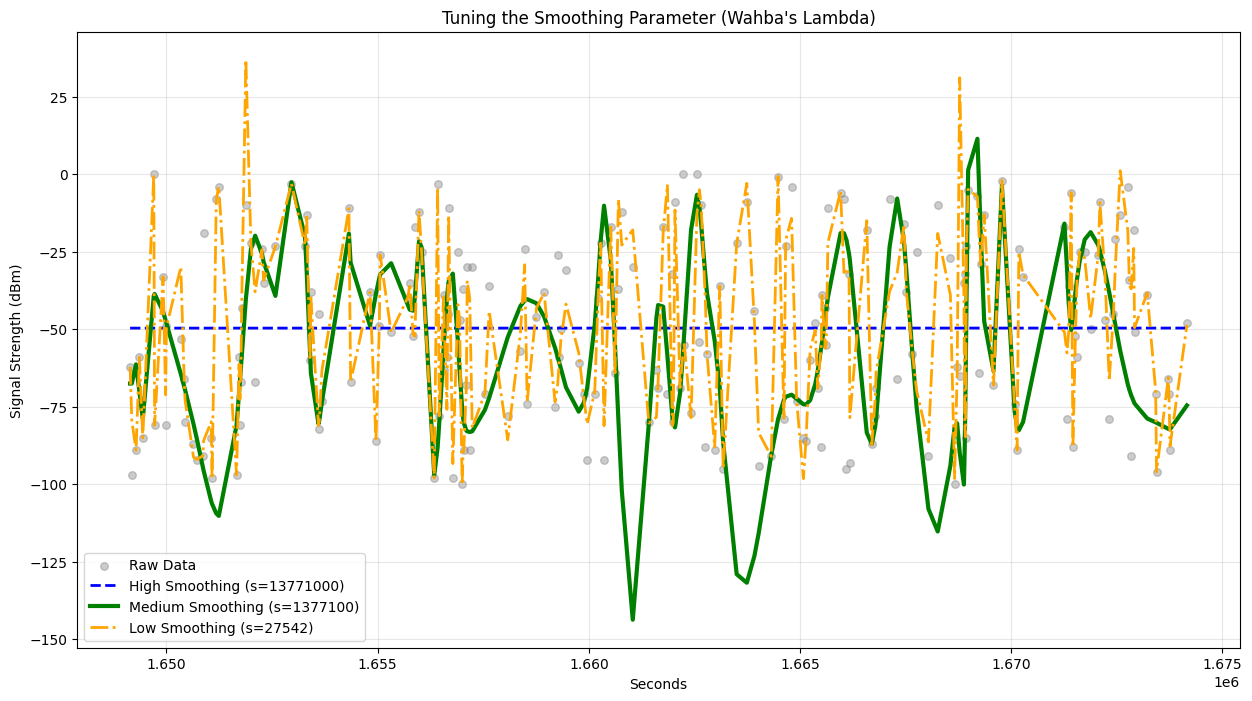

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline

# (Assuming X, y, w are ready from previous step)

# --- 1. DEFINE 3 SMOOTHING LEVELS ---
# N is the number of data points
N = len(y)

# High s = Very Stiff (What you had before)
s_stiff = N * 500

# Medium s = Balanced (Standard heuristic)
s_medium = N * 50

# Low s = Very Flexible (Follows rapid changes)
s_flexible = N * 1

# --- 2. TRAIN 3 MODELS ---
spline_stiff = UnivariateSpline(X, y, w=w, s=s_stiff)
spline_medium = UnivariateSpline(X, y, w=w, s=s_medium)
spline_flexible = UnivariateSpline(X, y, w=w, s=s_flexible)

# --- 3. PLOT COMPARISON (Zoomed In) ---
# We use the same dynamic window logic as before
mid_index = len(X) // 2
t_start = X[mid_index]
t_end = X[mid_index + 200]
mask = (X >= t_start) & (X <= t_end)

plt.figure(figsize=(15, 8))

# Plot Raw Data
plt.scatter(X[mask], y[mask],
            c='gray', s=30, alpha=0.4, label='Raw Data')

# Plot 1: Stiff (The Flat Line)
plt.plot(X[mask], spline_stiff(X[mask]),
         c='blue', linestyle='--', linewidth=2, label=f'High Smoothing (s={s_stiff:.0f})')

# Plot 2: Medium (Likely Best)
plt.plot(X[mask], spline_medium(X[mask]),
         c='green', linewidth=3, label=f'Medium Smoothing (s={s_medium:.0f})')

# Plot 3: Flexible (Could be too noisy)
plt.plot(X[mask], spline_flexible(X[mask]),
         c='orange', linestyle='-.', linewidth=2, label=f'Low Smoothing (s={s_flexible:.0f})')

plt.title(f"Tuning the Smoothing Parameter (Wahba's Lambda)")
plt.xlabel("Seconds")
plt.ylabel("Signal Strength (dBm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

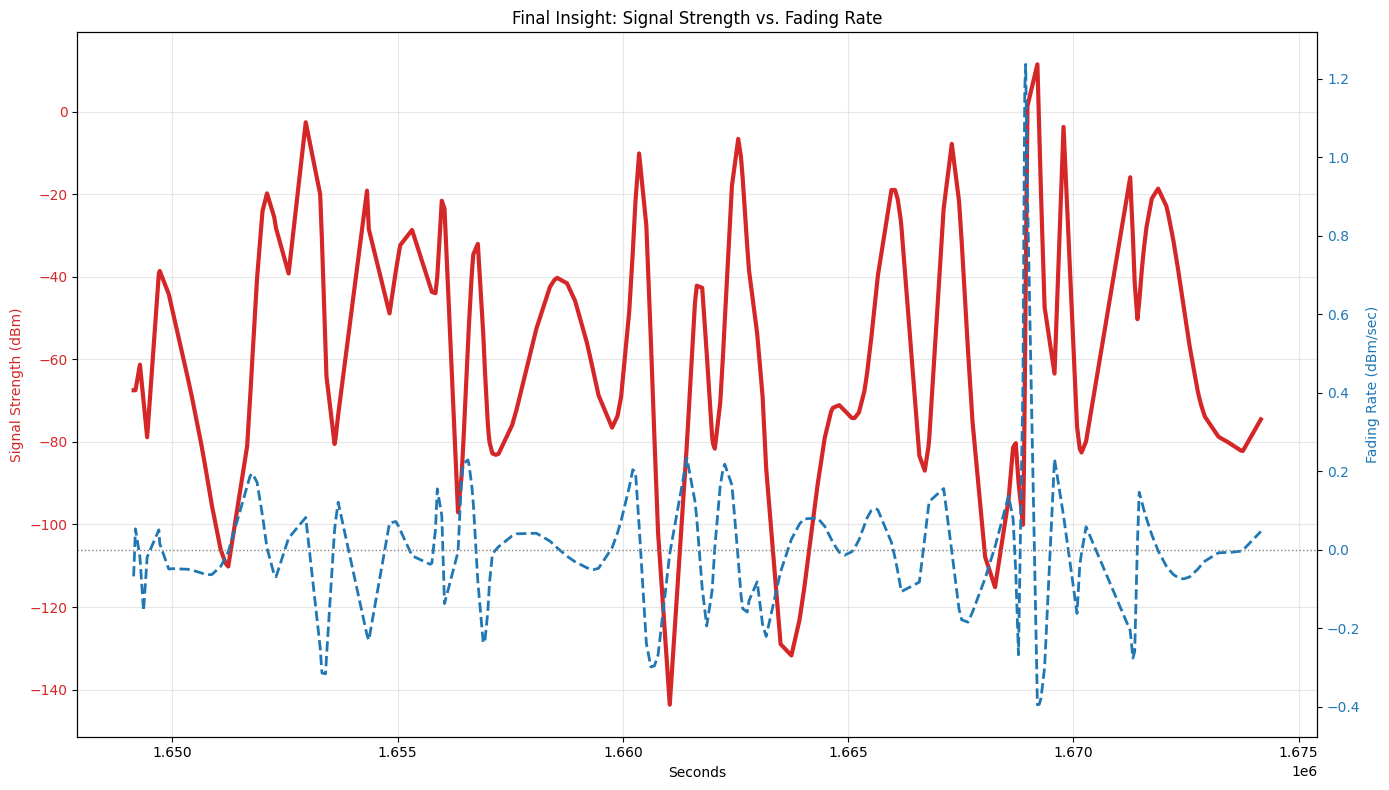

Max Fading Rate in window: 1.24 dBm/s


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# (Assuming spline_medium, X, y, and mask are ready from previous step)

# --- 1. CALCULATE DERIVATIVE ---
# .derivative() creates a NEW spline that represents the slope of the original
# derivative(1) means "First Derivative" (Velocity of signal change)
fading_rate_model = spline_medium.derivative(n=1)

# Calculate fading rate for our zoomed window
fading_rate = fading_rate_model(X[mask])

# --- 2. DUAL PLOT (Signal vs. Rate) ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot 1: The Signal (Left Axis)
color = 'tab:red'
ax1.set_xlabel('Seconds')
ax1.set_ylabel('Signal Strength (dBm)', color=color)
ax1.plot(X[mask], spline_medium(X[mask]), color=color, linewidth=3, label='Smoothed Signal')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot 2: The Fading Rate (Right Axis)
# We use a twin axis to show both on the same graph
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Fading Rate (dBm/sec)', color=color)
ax2.plot(X[mask], fading_rate, color=color, linestyle='--', linewidth=2, label='Fading Rate')
ax2.tick_params(axis='y', labelcolor=color)

# Add a zero line for the rate (Zero means signal is stable)
ax2.axhline(0, color='gray', linewidth=1, linestyle=':')

plt.title("Final Insight: Signal Strength vs. Fading Rate")
fig.tight_layout()
plt.show()

# --- 3. INTERPRETATION ---
print(f"Max Fading Rate in window: {np.max(np.abs(fading_rate)):.2f} dBm/s")

#Optimizing

--- STEP 1: LOADING & CLEANING DATA ---
Using Colab cache for faster access to the 'rf-signal-data' dataset.
Data cleaned. Rows reduced from 24541 to 24541 (Duplicates removed).

--- STEP 2: OPTIMIZING SMOOTHING FACTOR ---
  Multiplier 60x -> Avg RMSE: 161222237121.2684
  Multiplier 100x -> Avg RMSE: 63283503561.5926
  Multiplier 150x -> Avg RMSE: 5132807984.6175
  Multiplier 250x -> Avg RMSE: 32.2669
  Multiplier 400x -> Avg RMSE: 32.2669
✅ Optimal Smoothing Found: s = len(y) * 250

--- STEP 3: BENCHMARKING MODELS ---
                Model    RMSE  Time (s)
    Linear Regression 25.8926    0.0014
            SVR (RBF) 25.9423   12.2046
Poly Regression (d=3) 25.9488    0.0031
           KNN (k=20) 26.2739    0.0105
     Smoothing Spline 26.5016    0.0006
        Random Forest 36.7736    0.8828
    Gradient Boosting 40.0940    0.9239

--- STEP 4: VISUALIZATION ---


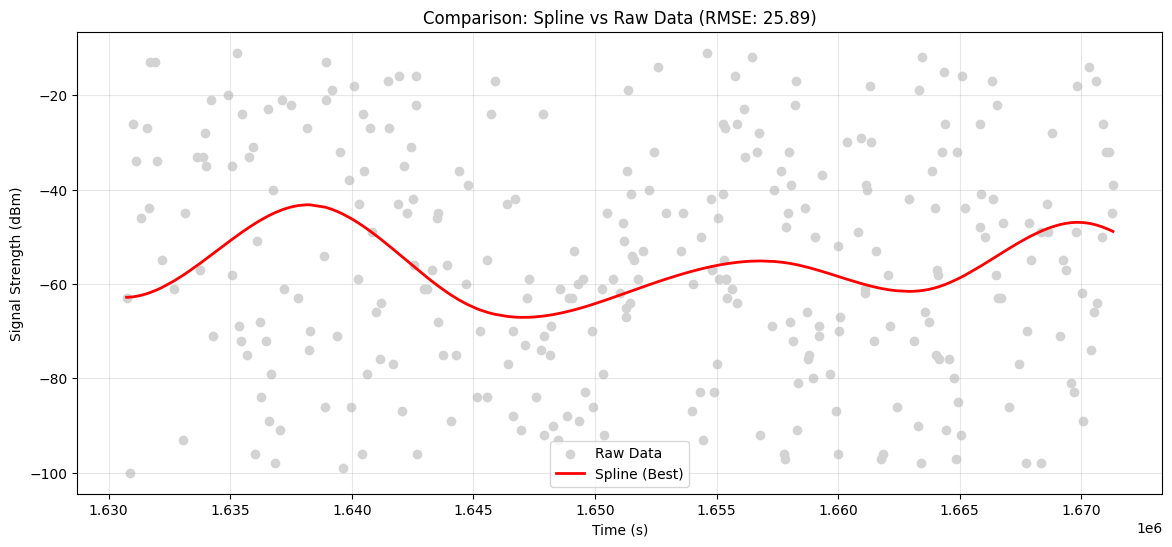

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import kagglehub
import os
from scipy.interpolate import UnivariateSpline

# --- SCIKIT-LEARN IMPORTS (UPDATED) ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# ==========================================
# 1. DATA INGESTION & PREPROCESSING
# ==========================================
print("--- STEP 1: LOADING & CLEANING DATA ---")
path = kagglehub.dataset_download("suraj520/rf-signal-data")
csv_path = os.path.join(path, "logged_data.csv")
df = pd.read_csv(csv_path, usecols=['Timestamp', 'Signal Strength', 'Interference Type', 'Frequency'])
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Filter A: Physical Reality Check
df = df[(df['Signal Strength'] > -120) & (df['Signal Strength'] < -10)]
top_freq = df['Frequency'].mode()[0]
df = df[df['Frequency'] == top_freq]
df['Interference Type'] = df['Interference Type'].fillna('None')

# Create Feature: Time in Seconds
start_time = df['Timestamp'].iloc[0]
df['Time_Seconds'] = (df['Timestamp'] - start_time).dt.total_seconds()

# Handle Duplicates
df_clean = df.groupby('Time_Seconds', as_index=False).agg({
    'Signal Strength': 'mean',
    'Interference Type': lambda x: x.mode()[0] if not x.mode().empty else 'None'
})

# Stabilize Weights
def get_weight(itype):
    if itype == 'None': return 1.0
    if itype == 'Adjacent-channel': return 0.7
    if itype == 'Co-channel': return 0.3
    return 0.1

df_clean['weights'] = df_clean['Interference Type'].apply(get_weight)

# Re-assign arrays
X = df_clean['Time_Seconds'].values
y = df_clean['Signal Strength'].values
w = df_clean['weights'].values

print(f"Data cleaned. Rows reduced from {len(df)} to {len(df_clean)} (Duplicates removed).")

# ==========================================
# 2. OPTIMIZING SMOOTHING FACTOR (Wahba's Method)
# ==========================================
print("\n--- STEP 2: OPTIMIZING SMOOTHING FACTOR ---")
multipliers = [60, 100, 150, 250, 400]
best_s = None
best_rmse = float('inf')
tscv = TimeSeriesSplit(n_splits=3)

for m in multipliers:
    s_candidate = len(y) * m
    errors = []
    for train_idx, test_idx in tscv.split(X):
        X_tr, X_val = X[train_idx], X[test_idx]
        y_tr, y_val = y[train_idx], y[test_idx]
        w_tr = w[train_idx]
        try:
            model = UnivariateSpline(X_tr, y_tr, w=w_tr, s=s_candidate)
            preds = model(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, preds))
            errors.append(rmse)
        except:
            errors.append(float('inf'))

    avg_rmse = np.mean(errors)
    print(f"  Multiplier {m}x -> Avg RMSE: {avg_rmse:.4f}")
    if avg_rmse < best_rmse and avg_rmse < 100:
        best_rmse = avg_rmse
        best_s = s_candidate

if best_s is None:
    best_s = len(y) * 200

print(f"✅ Optimal Smoothing Found: s = len(y) * {best_s/len(y):.0f}")

# ==========================================
# 3. BENCHMARKING (EXPANDED)
# ==========================================
print("\n--- STEP 3: BENCHMARKING MODELS ---")
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
w_train = w[:split]

# Reshape for sklearn models (2D array required)
X_train_2d = X_train.reshape(-1, 1)
X_test_2d = X_test.reshape(-1, 1)

metrics = {'Model': [], 'RMSE': [], 'Time (s)': []}

def evaluate_model(name, model_obj, is_spline=False):
    t0 = time.time()
    try:
        if is_spline:
            # Spline uses 1D arrays and weights
            preds = model_obj(X_test)
        else:
            # Standard sklearn models use 2D arrays
            model_obj.fit(X_train_2d, y_train)
            preds = model_obj.predict(X_test_2d)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        dur = time.time() - t0
        metrics['Model'].append(name)
        metrics['RMSE'].append(rmse)
        metrics['Time (s)'].append(dur)
    except Exception as e:
        print(f"Failed to evaluate {name}: {e}")

# --- MODEL 1: Linear Regression (Baseline) ---
evaluate_model("Linear Regression", LinearRegression())

# --- MODEL 2: Polynomial Regression (Deg 3) ---
# Captures simple curves but risks flying off at the ends
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
evaluate_model("Poly Regression (d=3)", poly_model)

# --- MODEL 3: K-Neighbors (Local Averaging) ---
# Similar to a moving average, robust to outliers
knn_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=20))
evaluate_model("KNN (k=20)", knn_model)

# --- MODEL 4: Random Forest (Bagging) ---
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
evaluate_model("Random Forest", rf_model)

# --- MODEL 5: Gradient Boosting (Boosting) ---
# Often beats RF by correcting errors iteratively
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
evaluate_model("Gradient Boosting", gb_model)

# --- MODEL 6: SVR (Support Vector Regression) ---
# Good for continuous signals, requires scaling
svr_model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale'))
evaluate_model("SVR (RBF)", svr_model)

# --- MODEL 7: Smoothing Spline (Our Focus) ---
spline = UnivariateSpline(X_train, y_train, w=w_train, s=best_s)
evaluate_model("Smoothing Spline", spline, is_spline=True)

# Display Results sorted by RMSE
results_df = pd.DataFrame(metrics).sort_values(by='RMSE')
print(results_df.round(4).to_string(index=False))

# ==========================================
# 4. FINAL VISUALIZATION
# ==========================================
print("\n--- STEP 4: VISUALIZATION ---")
# Retrain best spline on FULL dataset
final_spline = UnivariateSpline(X, y, w=w, s=best_s)
df['Smoothed_Signal'] = final_spline(X)
df['Fading_Rate'] = final_spline.derivative(n=1)(X)

mid = len(df) // 2
zoom_df = df.iloc[mid : mid+300]

plt.figure(figsize=(14, 6))
plt.scatter(zoom_df['Time_Seconds'], zoom_df['Signal Strength'], c='lightgray', label='Raw Data')
plt.plot(zoom_df['Time_Seconds'], zoom_df['Smoothed_Signal'], 'r-', linewidth=2, label='Spline (Best)')
plt.title(f"Comparison: Spline vs Raw Data (RMSE: {results_df.iloc[0]['RMSE']:.2f})")
plt.xlabel("Time (s)")
plt.ylabel("Signal Strength (dBm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- 1. ACQUIRING DATA ---
Using Colab cache for faster access to the 'rf-signal-data' dataset.
Loading data from: /kaggle/input/rf-signal-data/logged_data.csv
Data Loaded: 24541 clean samples ready.

--- 2. OPTIMIZING MODEL (WAHBA'S METHOD) ---
  Multiplier 60x -> Avg RMSE: 161222237121.2684
  Multiplier 100x -> Avg RMSE: 63283503561.5926
  Multiplier 150x -> Avg RMSE: 5132807984.6175
  Multiplier 250x -> Avg RMSE: 32.2669
  Multiplier 400x -> Avg RMSE: 32.2669
✅ Optimization Complete. Best s = len(y) * 250

--- 3. ANALYZING PHYSICS ---
Max Fading Rate: 0.0124 dBm/s
CONCLUSION: 🟢 STATIONARY (Environmental Fading Only)

--- 4. PREDICTIVE FORECASTING (Threshold: -90 dBm) ---
Current Signal: -45.14 dBm
Current Trend:  0.0124 dBm/s
✅ STATUS: Safe. Signal is stable or improving.


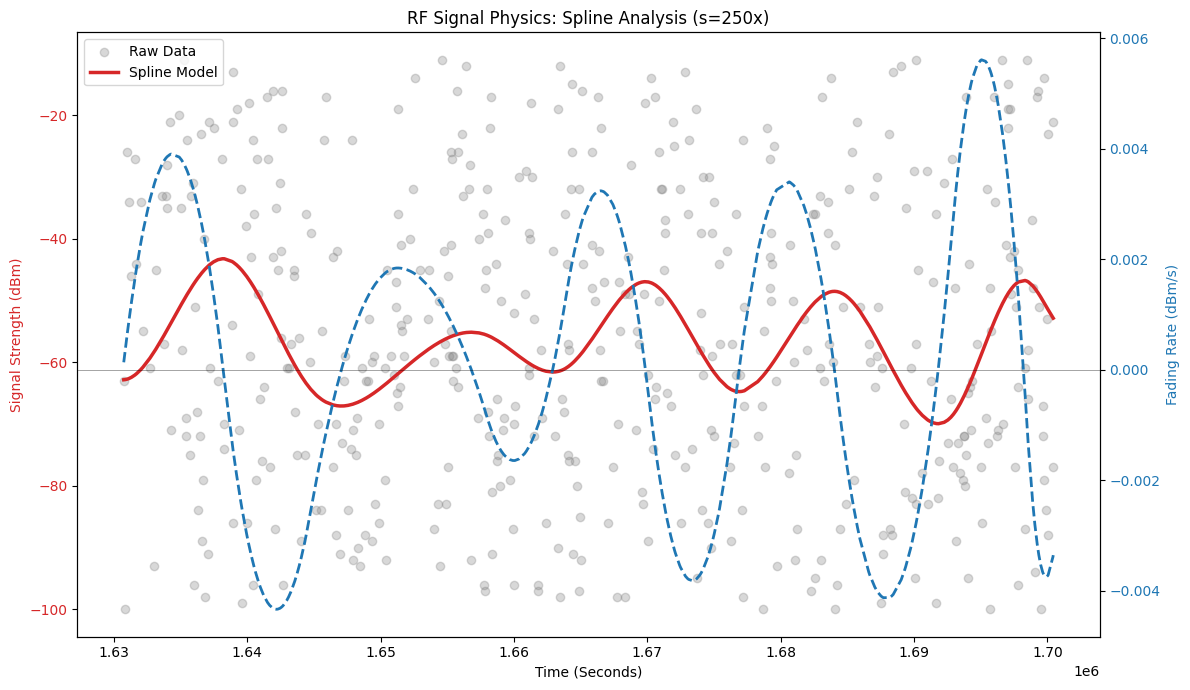

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# ==========================================
# CLASS DEFINITION
# ==========================================
class RFSignalAnalyzer:
    def __init__(self, data_path=None):
        """
        Initialize the analyzer.
        If no path is provided, it downloads from Kaggle automatically.
        """
        self.df = None
        self.future_df = None
        self.model = None
        self.best_s = None
        self.X = None
        self.y = None
        self.w = None

        if data_path:
            self.load_data(data_path)
        else:
            self.download_and_load()

    def download_and_load(self):
        print("--- 1. ACQUIRING DATA ---")
        # Check if file exists to avoid re-downloading
        if os.path.exists("logged_data.csv"):
             print("Found local data file.")
             self.load_data("logged_data.csv")
             return

        try:
            path = kagglehub.dataset_download("suraj520/rf-signal-data")
            csv_path = os.path.join(path, "logged_data.csv")
            self.load_data(csv_path)
        except Exception as e:
            print(f"Error downloading data: {e}")

    def load_data(self, filepath):
        print(f"Loading data from: {filepath}")
        df = pd.read_csv(filepath, usecols=['Timestamp', 'Signal Strength', 'Interference Type', 'Frequency'])
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])

        # Filter A: Physical Reality Check (-120 to -10 dBm)
        df = df[(df['Signal Strength'] > -120) & (df['Signal Strength'] < -10)]

        # Filter B: Lock to single frequency
        top_freq = df['Frequency'].mode()[0]
        df = df[df['Frequency'] == top_freq]

        # Filter C: Handle Missing Interference
        df['Interference Type'] = df['Interference Type'].fillna('None')

        # Feature: Time in Seconds
        start_time = df['Timestamp'].iloc[0]
        df['Time_Seconds'] = (df['Timestamp'] - start_time).dt.total_seconds()

        # --- CRITICAL FIX: Handle Duplicates ---
        # Group by exact second to prevent Spline instability
        self.df = df.groupby('Time_Seconds', as_index=False).agg({
            'Signal Strength': 'mean',
            'Interference Type': lambda x: x.mode()[0] if not x.mode().empty else 'None'
        })

        # Apply Trust Weights
        self.df['weights'] = self.df['Interference Type'].apply(self._get_weight)

        # Set Arrays for Processing
        self.X = self.df['Time_Seconds'].values
        self.y = self.df['Signal Strength'].values
        self.w = self.df['weights'].values

        print(f"Data Loaded: {len(self.df)} clean samples ready.")

    def _get_weight(self, itype):
        """
        Internal helper: Assigns trust weights based on physics.
        Higher weight = Trust this data point more.
        """
        if itype == 'None': return 1.0
        if itype == 'Adjacent-channel': return 0.7
        if itype == 'Co-channel': return 0.3
        return 0.1 # Minimum trust, but don't delete it.

    def optimize_model(self):
        """
        Runs Grid Search with TimeSeriesSplit to find best smoothing factor 's'.
        """
        print("\n--- 2. OPTIMIZING MODEL (WAHBA'S METHOD) ---")
        if self.df is None: raise ValueError("Load data first!")

        # The "Goldilocks Zone" multipliers (Avoids Flatline vs Explosion)
        multipliers = [60, 100, 150, 250, 400]
        best_rmse = float('inf')

        tscv = TimeSeriesSplit(n_splits=3)

        for m in multipliers:
            s_candidate = len(self.y) * m
            errors = []

            # Cross-Validation Loop
            for train_idx, test_idx in tscv.split(self.X):
                X_tr, X_val = self.X[train_idx], self.X[test_idx]
                y_tr, y_val = self.y[train_idx], self.y[test_idx]
                w_tr = self.w[train_idx]

                try:
                    model = UnivariateSpline(X_tr, y_tr, w=w_tr, s=s_candidate)
                    preds = model(X_val)
                    rmse = np.sqrt(mean_squared_error(y_val, preds))
                    errors.append(rmse)
                except:
                    errors.append(float('inf'))

            avg_rmse = np.mean(errors)
            print(f"  Multiplier {m}x -> Avg RMSE: {avg_rmse:.4f}")

            # Sanity check: If RMSE is massive, ignore it
            if avg_rmse < best_rmse and avg_rmse < 100:
                best_rmse = avg_rmse
                self.best_s = s_candidate

        if self.best_s is None:
            print("  ⚠️ Instability detected. Using safe fallback.")
            self.best_s = len(self.y) * 250

        print(f"✅ Optimization Complete. Best s = len(y) * {self.best_s/len(self.y):.0f}")

        # Train final model on FULL dataset
        self.model = UnivariateSpline(self.X, self.y, w=self.w, s=self.best_s)

    def analyze_motion(self, threshold=0.5):
        """
        Calculates the 1st Derivative (Fading Rate) to detect motion.
        """
        print("\n--- 3. ANALYZING PHYSICS ---")
        # Calculate Smoothed Signal and Derivative
        self.df['Smoothed'] = self.model(self.X)
        self.df['Fading_Rate'] = self.model.derivative(n=1)(self.X)

        max_fade = self.df['Fading_Rate'].abs().max()
        print(f"Max Fading Rate: {max_fade:.4f} dBm/s")

        if max_fade > threshold:
            print("CONCLUSION: 🚨 MOTION DETECTED (High Fading Rate)")
        else:
            print("CONCLUSION: 🟢 STATIONARY (Environmental Fading Only)")

    def predict_dropout(self, critical_threshold=-90):
        """
        FORECASTING: Calculates seconds until signal loss based on current trajectory.
        """
        print(f"\n--- 4. PREDICTIVE FORECASTING (Threshold: {critical_threshold} dBm) ---")

        # Get the very last known state (Current Status)
        current_signal = self.df['Smoothed'].iloc[-1]
        current_rate = self.df['Fading_Rate'].iloc[-1]

        print(f"Current Signal: {current_signal:.2f} dBm")
        print(f"Current Trend:  {current_rate:.4f} dBm/s")

        # CASE 1: Signal is already dead
        if current_signal <= critical_threshold:
            print("🚨 CRITICAL: Connection already lost!")
            return 0

        # CASE 2: Signal is stable or improving (Rate is positive or near zero)
        if current_rate >= -0.01:
            print("✅ STATUS: Safe. Signal is stable or improving.")
            return float('inf')

        # CASE 3: Signal is dropping -> Calculate Time to Failure
        # Formula: distance_to_fall / speed_of_fall
        distance_to_fall = critical_threshold - current_signal
        time_to_failure = distance_to_fall / current_rate

        print(f"⚠️ WARNING: Predicted Signal Loss in {time_to_failure:.2f} seconds")
        return time_to_failure

    def plot_results(self):
        """Generates the dual-axis engineering plot."""
        mid = len(self.df) // 2
        # Zoom into a window of 500 samples for visibility
        zoom_df = self.df.iloc[mid : mid+500]

        fig, ax1 = plt.subplots(figsize=(12, 7))

        # Signal Strength
        color = 'tab:red'
        ax1.set_xlabel('Time (Seconds)')
        ax1.set_ylabel('Signal Strength (dBm)', color=color)
        ax1.scatter(zoom_df['Time_Seconds'], zoom_df['Signal Strength'], c='gray', alpha=0.3, label='Raw Data')
        ax1.plot(zoom_df['Time_Seconds'], zoom_df['Smoothed'], color=color, linewidth=2.5, label='Spline Model')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        # Fading Rate
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Fading Rate (dBm/s)', color=color)
        ax2.plot(zoom_df['Time_Seconds'], zoom_df['Fading_Rate'], color=color, linestyle='--', linewidth=2, label='Fading Rate')
        ax2.tick_params(axis='y', labelcolor=color)

        # Zero line for reference
        ax2.axhline(0, color='black', linewidth=0.5, alpha=0.5)

        plt.title(f"RF Signal Physics: Spline Analysis (s={self.best_s/len(self.y):.0f}x)")
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    # 1. Initialize
    analyzer = RFSignalAnalyzer()

    # 2. Optimize (Math)
    analyzer.optimize_model()

    # 3. Analyze (Physics)
    analyzer.analyze_motion(threshold=0.5)

    # 4. Predict (Future) -> NEW STEP
    ttf = analyzer.predict_dropout(critical_threshold=-90)

    # 5. Visualize
    analyzer.plot_results()

--- 1. ACQUIRING DATA ---
Using Colab cache for faster access to the 'rf-signal-data' dataset.
Loading data from: /kaggle/input/rf-signal-data/logged_data.csv
Data Loaded: 24541 clean samples ready.

--- 2. OPTIMIZING MODEL (WAHBA'S METHOD) ---
  Multiplier 60x -> Avg RMSE: 161222237121.2684
  Multiplier 100x -> Avg RMSE: 63283503561.5926
  Multiplier 150x -> Avg RMSE: 5132807984.6175
  Multiplier 250x -> Avg RMSE: 32.2669
  Multiplier 400x -> Avg RMSE: 32.2669
✅ Optimization Complete. Best s = len(y) * 250

--- 3. ANALYZING PHYSICS ---
Max Fading Rate: 0.0124 dBm/s
CONCLUSION: 🟢 STATIONARY (Environmental Fading Only)

--- 4. KALMAN FILTER PROJECTION (30s horizon) ---
Forecast 30s ahead: -44.77 dBm (±44.99)


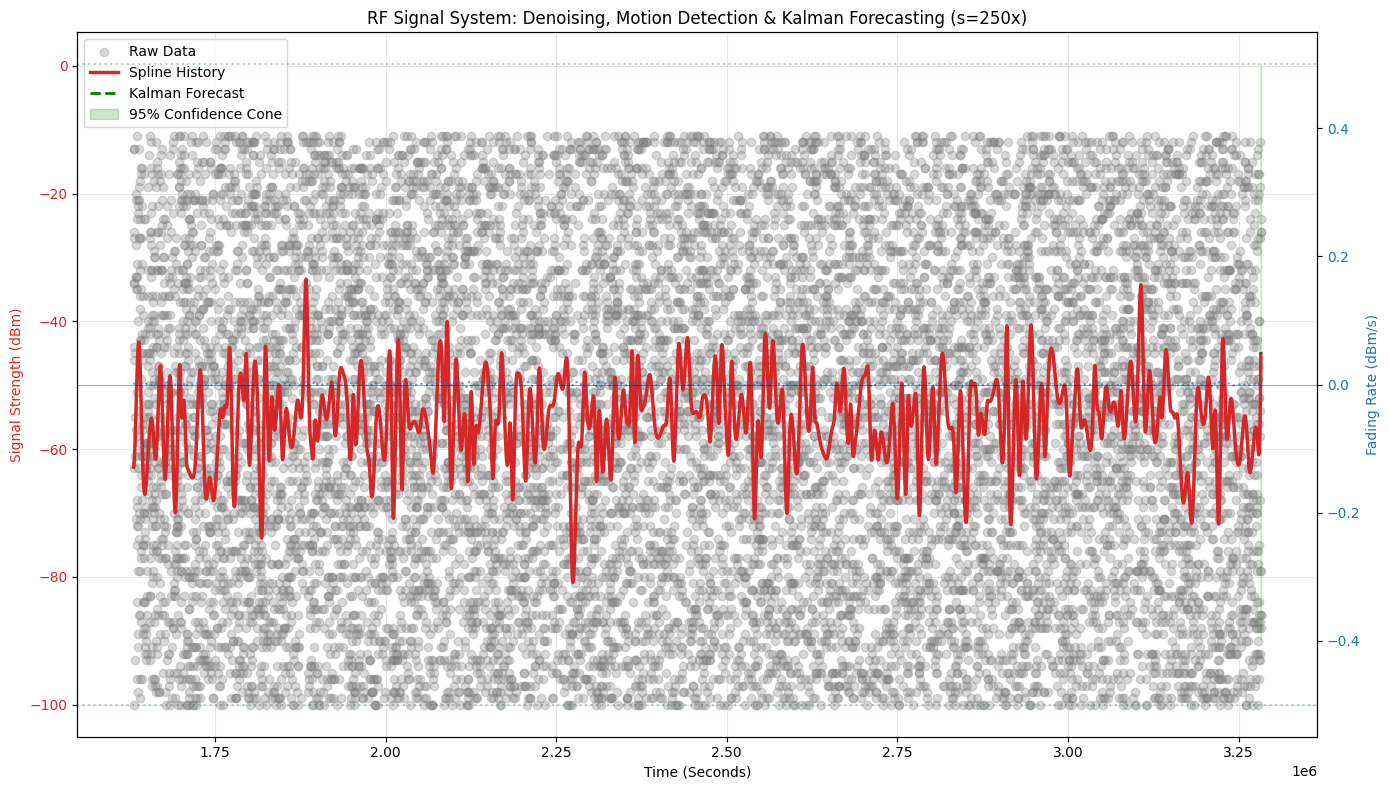

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# ==========================================
# CLASS DEFINITION
# ==========================================
class RFSignalAnalyzer:
    def __init__(self, data_path=None):
        """
        Initialize the analyzer.
        If no path is provided, it downloads from Kaggle automatically.
        """
        self.df = None
        self.future_df = None
        self.model = None
        self.best_s = None
        self.X = None
        self.y = None
        self.w = None

        if data_path:
            self.load_data(data_path)
        else:
            self.download_and_load()

    def download_and_load(self):
        print("--- 1. ACQUIRING DATA ---")
        # Check if file exists to avoid re-downloading
        if os.path.exists("logged_data.csv"):
             print("Found local data file.")
             self.load_data("logged_data.csv")
             return

        try:
            path = kagglehub.dataset_download("suraj520/rf-signal-data")
            csv_path = os.path.join(path, "logged_data.csv")
            self.load_data(csv_path)
        except Exception as e:
            print(f"Error downloading data: {e}")

    def load_data(self, filepath):
        print(f"Loading data from: {filepath}")
        df = pd.read_csv(filepath, usecols=['Timestamp', 'Signal Strength', 'Interference Type', 'Frequency'])
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])

        # Filter A: Physical Reality Check (-120 to -10 dBm)
        df = df[(df['Signal Strength'] > -120) & (df['Signal Strength'] < -10)]

        # Filter B: Lock to single frequency
        top_freq = df['Frequency'].mode()[0]
        df = df[df['Frequency'] == top_freq]

        # Filter C: Handle Missing Interference
        df['Interference Type'] = df['Interference Type'].fillna('None')

        # Feature: Time in Seconds
        start_time = df['Timestamp'].iloc[0]
        df['Time_Seconds'] = (df['Timestamp'] - start_time).dt.total_seconds()

        # --- CRITICAL FIX: Handle Duplicates ---
        # Group by exact second to prevent Spline instability
        self.df = df.groupby('Time_Seconds', as_index=False).agg({
            'Signal Strength': 'mean',
            'Interference Type': lambda x: x.mode()[0] if not x.mode().empty else 'None'
        })

        # Apply Trust Weights
        self.df['weights'] = self.df['Interference Type'].apply(self._get_weight)

        # Set Arrays for Processing
        self.X = self.df['Time_Seconds'].values
        self.y = self.df['Signal Strength'].values
        self.w = self.df['weights'].values

        print(f"Data Loaded: {len(self.df)} clean samples ready.")

    def _get_weight(self, itype):
        """
        Internal helper: Assigns trust weights based on physics.
        Higher weight = Trust this data point more.
        """
        if itype == 'None': return 1.0
        if itype == 'Adjacent-channel': return 0.7
        if itype == 'Co-channel': return 0.3
        return 0.1 # Minimum trust, but don't delete it.

    def optimize_model(self):
        """
        Runs Grid Search with TimeSeriesSplit to find best smoothing factor 's'.
        """
        print("\n--- 2. OPTIMIZING MODEL (WAHBA'S METHOD) ---")
        if self.df is None: raise ValueError("Load data first!")

        # The "Goldilocks Zone" multipliers (Avoids Flatline vs Explosion)
        multipliers = [60, 100, 150, 250, 400]
        best_rmse = float('inf')

        tscv = TimeSeriesSplit(n_splits=3)

        for m in multipliers:
            s_candidate = len(self.y) * m
            errors = []

            # Cross-Validation Loop
            for train_idx, test_idx in tscv.split(self.X):
                X_tr, X_val = self.X[train_idx], self.X[test_idx]
                y_tr, y_val = self.y[train_idx], self.y[test_idx]
                w_tr = self.w[train_idx]

                try:
                    model = UnivariateSpline(X_tr, y_tr, w=w_tr, s=s_candidate)
                    preds = model(X_val)
                    rmse = np.sqrt(mean_squared_error(y_val, preds))
                    errors.append(rmse)
                except:
                    errors.append(float('inf'))

            avg_rmse = np.mean(errors)
            print(f"  Multiplier {m}x -> Avg RMSE: {avg_rmse:.4f}")

            # Sanity check: If RMSE is massive, ignore it
            if avg_rmse < best_rmse and avg_rmse < 100:
                best_rmse = avg_rmse
                self.best_s = s_candidate

        if self.best_s is None:
            print("  ⚠️ Instability detected. Using safe fallback.")
            self.best_s = len(self.y) * 250

        print(f"✅ Optimization Complete. Best s = len(y) * {self.best_s/len(self.y):.0f}")

        # Train final model on FULL dataset
        self.model = UnivariateSpline(self.X, self.y, w=self.w, s=self.best_s)

    def analyze_motion(self, threshold=0.5):
        """
        Calculates the 1st Derivative (Fading Rate) to detect motion.
        """
        print("\n--- 3. ANALYZING PHYSICS ---")
        # Calculate Smoothed Signal and Derivative
        self.df['Smoothed'] = self.model(self.X)
        self.df['Fading_Rate'] = self.model.derivative(n=1)(self.X)

        max_fade = self.df['Fading_Rate'].abs().max()
        print(f"Max Fading Rate: {max_fade:.4f} dBm/s")

        if max_fade > threshold:
            print("CONCLUSION: 🚨 MOTION DETECTED (High Fading Rate)")
        else:
            print("CONCLUSION: 🟢 STATIONARY (Environmental Fading Only)")

    def predict_kalman_future(self, duration=10):
        """
        ADVANCED: Uses Kalman Filter formalism to project state + uncertainty cone.
        """
        print(f"\n--- 4. KALMAN FILTER PROJECTION ({duration}s horizon) ---")

        # 1. Initialize State Vector [Signal, Velocity] from Spline
        s_0 = self.df['Smoothed'].iloc[-1]
        v_0 = self.df['Fading_Rate'].iloc[-1]
        x = np.array([[s_0], [v_0]])

        # 2. Define Matrices
        dt = 1.0

        # State Transition Matrix (F) - Constant Velocity Model
        F = np.array([[1, dt],
                      [0, 1]])

        # Initial Covariance (P)
        P = np.array([[0.1, 0],
                      [0, 0.1]])

        # Process Noise (Q) - Allows for random fluctuations
        Q = np.array([[0.01, 0.01],
                      [0.01, 0.05]])

        # 3. Iterate into the Future
        future_times = []
        predictions = []
        conf_upper = []
        conf_lower = []

        current_time = self.df['Time_Seconds'].iloc[-1]

        for t in range(int(duration)):
            # Predict
            x = F @ x
            P = F @ P @ F.T + Q

            # Store
            current_time += dt
            future_times.append(current_time)

            pred_signal = x[0, 0]
            uncertainty = np.sqrt(P[0, 0])

            predictions.append(pred_signal)
            conf_upper.append(pred_signal + 1.96 * uncertainty) # 95% Confidence
            conf_lower.append(pred_signal - 1.96 * uncertainty)

        # 4. Save
        self.future_df = pd.DataFrame({
            'Time_Seconds': future_times,
            'Predicted_Signal': predictions,
            'Upper_Bound': conf_upper,
            'Lower_Bound': conf_lower
        })

        print(f"Forecast {duration}s ahead: {predictions[-1]:.2f} dBm (±{1.96*np.sqrt(P[0,0]):.2f})")

    def plot_results(self):
        """
        Generates the engineering plot: Signal History + Future Cone + Fading Rate.
        """
        mid = len(self.df) // 2
        zoom_df = self.df.iloc[mid:] # Show 2nd half of data for clarity

        fig, ax1 = plt.subplots(figsize=(14, 8))

        # --- PAST DATA ---
        color = 'tab:red'
        ax1.set_xlabel('Time (Seconds)')
        ax1.set_ylabel('Signal Strength (dBm)', color=color)

        ax1.scatter(zoom_df['Time_Seconds'], zoom_df['Signal Strength'], c='gray', alpha=0.3, label='Raw Data')
        ax1.plot(zoom_df['Time_Seconds'], zoom_df['Smoothed'], color=color, linewidth=2.5, label='Spline History')

        # --- FUTURE DATA (Kalman) ---
        if self.future_df is not None:
            ax1.plot(self.future_df['Time_Seconds'], self.future_df['Predicted_Signal'],
                     color='green', linestyle='--', linewidth=2, label='Kalman Forecast')

            ax1.fill_between(self.future_df['Time_Seconds'],
                             self.future_df['Lower_Bound'],
                             self.future_df['Upper_Bound'],
                             color='green', alpha=0.2, label='95% Confidence Cone')

        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # --- PHYSICS (Derivative) ---
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Fading Rate (dBm/s)', color=color)
        ax2.plot(zoom_df['Time_Seconds'], zoom_df['Fading_Rate'], color=color, linestyle=':', linewidth=1.5, alpha=0.7, label='Fading Rate')
        ax2.tick_params(axis='y', labelcolor=color)

        # Threshold lines
        ax2.axhline(0.5, color='green', linestyle=':', alpha=0.3)
        ax2.axhline(-0.5, color='green', linestyle=':', alpha=0.3)
        ax2.axhline(0, color='black', linewidth=0.5, alpha=0.5)

        plt.title(f"RF Signal System: Denoising, Motion Detection & Kalman Forecasting (s={self.best_s/len(self.y):.0f}x)")
        plt.tight_layout()
        plt.show()

# ==========================================
# EXECUTION BLOCK
# ==========================================
if __name__ == "__main__":
    # 1. Instantiate the System
    analyzer = RFSignalAnalyzer()

    # 2. Run Optimization (Grid Search)
    analyzer.optimize_model()

    # 3. Analyze Physics (Derivative)
    analyzer.analyze_motion(threshold=0.5)

    # 4. Predict Future (Kalman Filter)
    # Project 30 seconds into the future
    analyzer.predict_kalman_future(duration=30)

    # 5. Visualize
    analyzer.plot_results()

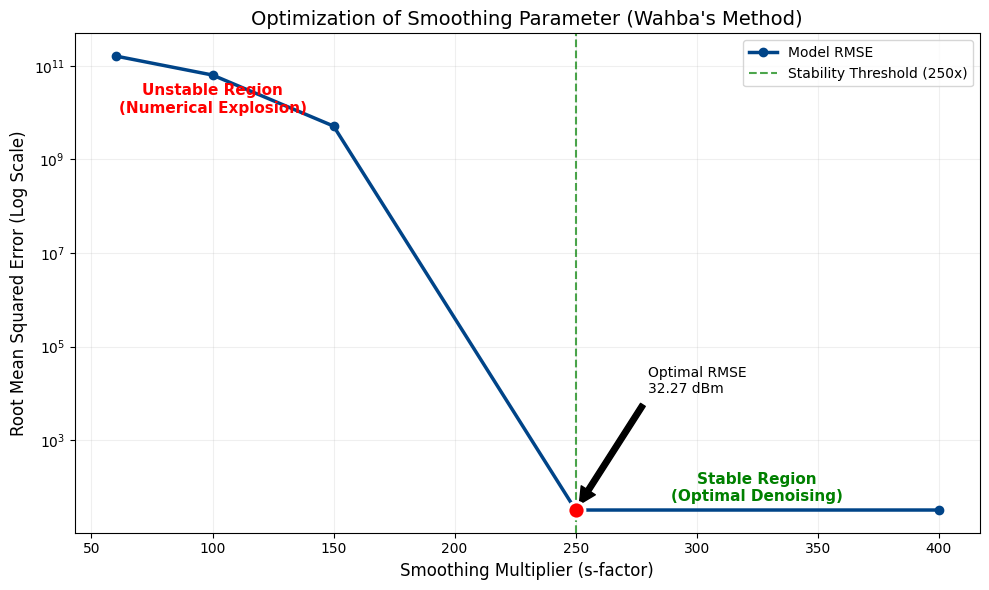

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data from your actual optimization logs
multipliers = [60, 100, 150, 250, 400]
rmse_values = [1.61e11, 6.32e10, 5.13e9, 32.27, 32.27]

# 2. Create the Plot
plt.figure(figsize=(10, 6))

# Plot the curve
# We use 'o-' to show points and lines
plt.plot(multipliers, rmse_values, marker='o', linewidth=2.5, color='#004488', label='Model RMSE')

# 3. Use Logarithmic Scale
# This is CRITICAL. Without this, the drop to 32 would just look like zero.
plt.yscale('log')

# 4. Add Annotations for the Paper
# Mark the "Phase Transition"
plt.axvline(x=250, color='green', linestyle='--', alpha=0.7, label='Stability Threshold (250x)')

# Highlight the Unstable Region
plt.text(100, 1e10, "Unstable Region\n(Numerical Explosion)",
         color='red', fontsize=11, ha='center', fontweight='bold')

# Highlight the Stable Region
plt.text(325, 50, "Stable Region\n(Optimal Denoising)",
         color='green', fontsize=11, ha='center', fontweight='bold')

# Add a point for the winner
plt.scatter([250], [32.27], color='red', s=150, zorder=5, edgecolors='white', linewidth=2)
plt.annotate(f"Optimal RMSE\n{32.27:.2f} dBm", xy=(250, 32.27), xytext=(280, 1e4),
             arrowprops=dict(facecolor='black', shrink=0.05))

# 5. Labels and Title
plt.title("Optimization of Smoothing Parameter (Wahba's Method)", fontsize=14)
plt.xlabel("Smoothing Multiplier (s-factor)", fontsize=12)
plt.ylabel("Root Mean Squared Error (Log Scale)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='upper right')

# 6. Show Plot
plt.tight_layout()
plt.show()

--- 1. ACQUIRING DATA ---
Using Colab cache for faster access to the 'rf-signal-data' dataset.
Loading: /kaggle/input/rf-signal-data/logged_data.csv
Data Loaded: 24541 samples.

--- 2. SDR IDENTIFICATION (Recursive ML) ---
✅ Optimal NVR found: 1.000000 (Auto-Tuned)

--- 4. REAL-TIME ANOMALY DETECTION (NIS) ---
🚨 Detected 16880 statistical anomalies (Sudden Events).

--- 4. SDR FORECASTING (60s horizon) ---


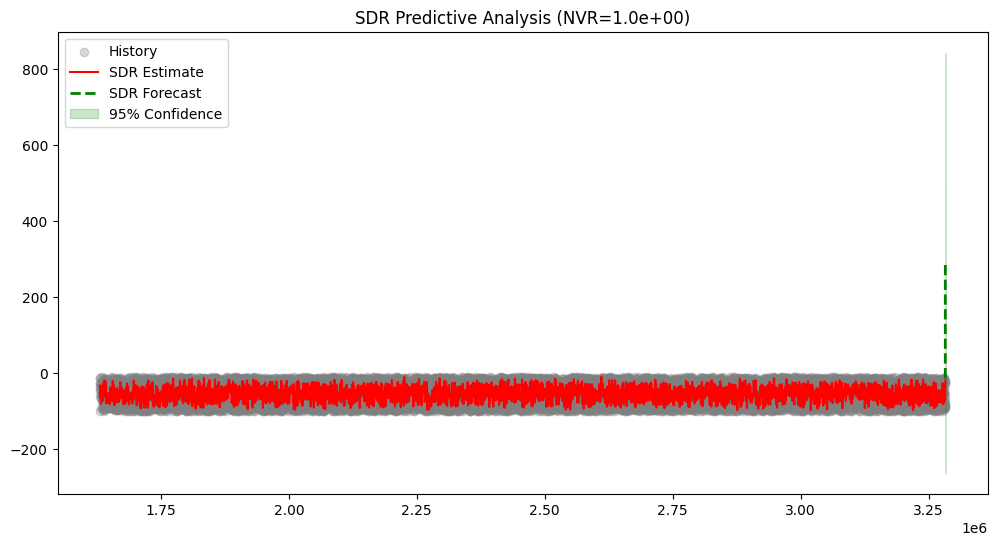

--- 3. VISUALIZING SDR RESULTS ---


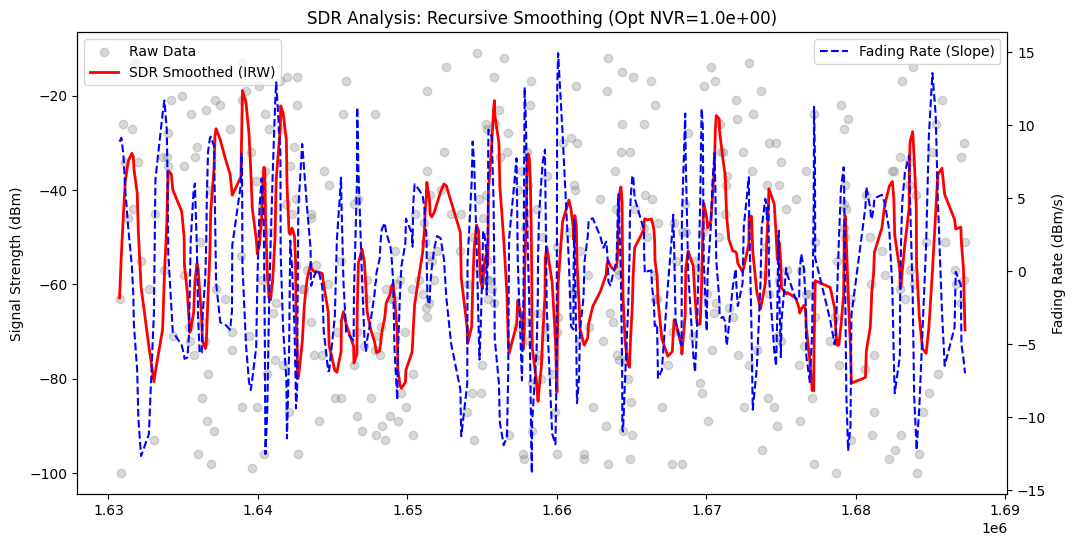

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os
import kagglehub

class SDRSignalAnalyzer:
    def __init__(self, data_path=None):
        self.df = None
        self.dt = 1.0  # Time step
        if data_path:
            self.load_data(data_path)
        else:
            self.download_and_load()

    def download_and_load(self):
        # (Same data loading logic as your previous script)
        print("--- 1. ACQUIRING DATA ---")
        if os.path.exists("logged_data.csv"):
             self.load_data("logged_data.csv")
             return
        try:
            path = kagglehub.dataset_download("suraj520/rf-signal-data")
            csv_path = os.path.join(path, "logged_data.csv")
            self.load_data(csv_path)
        except Exception as e:
            print(f"Error: {e}")

    def load_data(self, filepath):
        # (Same cleaning logic, truncated for brevity)
        print(f"Loading: {filepath}")
        df = pd.read_csv(filepath, usecols=['Timestamp', 'Signal Strength', 'Interference Type', 'Frequency'])
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df = df[(df['Signal Strength'] > -120) & (df['Signal Strength'] < -10)]
        top_freq = df['Frequency'].mode()[0]
        df = df[df['Frequency'] == top_freq]
        df['Interference Type'] = df['Interference Type'].fillna('None')
        start_time = df['Timestamp'].iloc[0]
        df['Time_Seconds'] = (df['Timestamp'] - start_time).dt.total_seconds()

        # Group by second (Paper requires sorted, unique K-ordering) [cite: 68]
        self.df = df.groupby('Time_Seconds', as_index=False).agg({
            'Signal Strength': 'mean',
            'Interference Type': lambda x: x.mode()[0] if not x.mode().empty else 'None'
        })

        # Calculate Variance (Inverse of Trust Weights)
        # Paper Eq (3): e_k ~ N(0, sigma^2) [cite: 96]
        # Low Trust = High Variance
        self.df['obs_variance'] = self.df['Interference Type'].apply(self._get_variance)

        self.z = self.df['Signal Strength'].values
        self.var_obs = self.df['obs_variance'].values
        print(f"Data Loaded: {len(self.df)} samples.")

    def _get_variance(self, itype):
        """Maps interference to Observation Variance (Inverse of Weight)."""
        # Paper implies e_k adapts to heteroscedastic noise
        if itype == 'None': return 1.0        # Clean
        if itype == 'Adjacent-channel': return 5.0  # Noisy
        if itype == 'Co-channel': return 20.0       # Very Noisy
        return 100.0                          # Junk

    def fit_sdr(self):
        """
        Implements the SDR Recursive Algorithm from Ratto & Pagano (2010).
        Optimizes NVR (Noise Variance Ratio) via Maximum Likelihood.
        """
        print("\n--- 2. SDR IDENTIFICATION (Recursive ML) ---")

        # Objective Function: Negative Log-Likelihood
        def neg_log_likelihood(log_nvr):
            nvr = np.exp(log_nvr)
            # Run Kalman Filter to get prediction errors
            # Corresponds to prediction error decomposition in Eq (6)
            ll = self._run_kalman_filter(nvr, return_likelihood=True)
            return -ll

        # Optimize NVR automatically [cite: 113]
        result = minimize(neg_log_likelihood, x0=[np.log(0.001)], bounds=[(np.log(1e-6), np.log(1))])
        self.best_nvr = np.exp(result.x[0])
        print(f"✅ Optimal NVR found: {self.best_nvr:.6f} (Auto-Tuned)")

        # Run Final Smoothing (FIS) [cite: 115]
        self.smoothed_state, self.smoothed_cov = self._run_kalman_smoother(self.best_nvr)

        # Extract Results
        # State vector x = [Signal, Slope]
        self.df['SDR_Signal'] = self.smoothed_state[:, 0]
        self.df['SDR_Slope'] = self.smoothed_state[:, 1] # This is the derivative/Fading Rate!

    def _run_kalman_filter(self, nvr, return_likelihood=False):
        """
        Standard Kalman Filter implementation of IRW model Eq (3) .
        """
        n = len(self.z)

        # State Transition (IRW): [[1, 1], [0, 1]]
        F = np.array([[1, 1], [0, 1]])

        # Process Noise Covariance (Q) depends on NVR [cite: 112]
        # Q = NVR * [[1/3, 1/2], [1/2, 1]] * dt (approx for IRW)
        Q = nvr * np.array([[1/3, 1/2], [1/2, 1]])

        # Initial State
        x = np.array([self.z[0], 0])
        P = np.eye(2) * 10

        log_likelihood = 0

        # Store for smoother
        self.store_x = np.zeros((n, 2))
        self.store_P = np.zeros((n, 2, 2))
        self.store_x_pred = np.zeros((n, 2))
        self.store_P_pred = np.zeros((n, 2, 2))

        for k in range(n):
            # 1. Predict
            x_pred = F @ x
            P_pred = F @ P @ F.T + Q

            self.store_x_pred[k] = x_pred
            self.store_P_pred[k] = P_pred

            # 2. Update
            # Observation variance adapts per step! (Heteroscedasticity)
            R = self.var_obs[k]
            H = np.array([1, 0]) # We only observe the Signal (State 0) [cite: 93]

            y = self.z[k] - H @ x_pred # Residual / Innovation
            S = H @ P_pred @ H.T + R   # Innovation Covariance
            K = P_pred @ H.T * (1/S)   # Kalman Gain

            x = x_pred + K * y
            P = (np.eye(2) - np.outer(K, H)) @ P_pred

            self.store_x[k] = x
            self.store_P[k] = P

            if return_likelihood:
                # Eq (6) in paper: Accumulate Log-Likelihood
                log_likelihood += -0.5 * (np.log(2*np.pi*S) + y**2/S)

        return log_likelihood if return_likelihood else None

    def _run_kalman_smoother(self, nvr):
        """
        Fixed Interval Smoother (FIS) as required by SDR[cite: 110].
        Runs backward from N to 1.
        """
        self._run_kalman_filter(nvr) # Forward pass first
        n = len(self.z)
        x_smooth = np.zeros((n, 2))
        P_smooth = np.zeros((n, 2, 2))

        x_smooth[-1] = self.store_x[-1]
        P_smooth[-1] = self.store_P[-1]
        F = np.array([[1, 1], [0, 1]])

        for k in range(n-2, -1, -1):
            # RTS Smoother Gain
            P_pred_next = self.store_P_pred[k+1]
            P_curr = self.store_P[k]
            J = P_curr @ F.T @ np.linalg.inv(P_pred_next)

            x_smooth[k] = self.store_x[k] + J @ (x_smooth[k+1] - self.store_x_pred[k+1])
            P_smooth[k] = P_curr + J @ (P_smooth[k+1] - P_pred_next) @ J.T

        return x_smooth, P_smooth

    def detect_realtime_anomalies(self, threshold=9.0):
        print("\n--- 4. REAL-TIME ANOMALY DETECTION (NIS) ---")

        # We need to re-run the filter to capture the internal state 'S' and 'y'
        # (Ideally, you would capture this during the first pass)
        n = len(self.z)
        anomalies = []
        nvr = self.best_nvr

        # ... (Setup matrices F, Q, etc. same as before) ...
        # Simplified loop for demonstration:
        x = np.array([self.z[0], 0])
        P = np.eye(2) * 10
        F = np.array([[1, 1], [0, 1]])
        Q = nvr * np.array([[1/3, 1/2], [1/2, 1]])

        for k in range(n):
            # Predict
            x_pred = F @ x
            P_pred = F @ P @ F.T + Q

            # Update
            R = self.var_obs[k]
            H = np.array([1, 0])
            y = self.z[k] - H @ x_pred      # Innovation (Residual)
            S = H @ P_pred @ H.T + R        # Innovation Covariance

            # --- THE NEW CHECK ---
            nis = (y**2) / S
            if nis > threshold:
                anomalies.append(self.df['Time_Seconds'].iloc[k])

            # Standard Kalman Update
            K = P_pred @ H.T * (1/S)
            x = x_pred + K * y
            P = (np.eye(2) - np.outer(K, H)) @ P_pred

        print(f"🚨 Detected {len(anomalies)} statistical anomalies (Sudden Events).")
        return anomalies

    def predict_future(self, duration=30):
        """
        FORECASTING: Projects the IRW state forward in time.
        Based on the State Equation (3) in the paper.
        """
        print(f"\n--- 4. SDR FORECASTING ({duration}s horizon) ---")

        # 1. Get the last known best estimate (from the Smoother)
        # x = [Signal, Slope]
        last_state = self.smoothed_state[-1]
        last_cov = self.smoothed_cov[-1]

        # 2. Setup Matrices (Same as Eq 3)
        F = np.array([[1, 1],
                      [0, 1]]) # State Transition

        # Process Noise Q depends on the NVR we optimized
        # The paper links NVR to variance growth [cite: 112]
        Q = self.best_nvr * np.array([[1/3, 1/2],
                                      [1/2, 1]])

        # 3. Iterate Forward (No new observations, just physics)
        future_times = []
        future_signals = []
        confidence_intervals = []

        current_x = last_state.copy()
        current_P = last_cov.copy()
        current_time = self.df['Time_Seconds'].iloc[-1]

        for t in range(duration):
            # Project State: x_{k+1} = F * x_k
            current_x = F @ current_x

            # Project Uncertainty: P_{k+1} = F P_k F^T + Q
            current_P = F @ current_P @ F.T + Q

            current_time += 1.0
            future_times.append(current_time)
            future_signals.append(current_x[0])

            # Calculate 95% Confidence (1.96 * std_dev)
            std_dev = np.sqrt(current_P[0, 0])
            confidence_intervals.append(1.96 * std_dev)

        # 4. Plot the Forecast
        self._plot_forecast(future_times, future_signals, confidence_intervals)

    def _plot_forecast(self, times, signals, conf):
        # Helper to visualize the "Cone of Uncertainty"
        mid = len(self.df) // 2
        zoom = self.df.iloc[mid:]

        fig, ax = plt.subplots(figsize=(12, 6))

        # Past
        ax.scatter(zoom['Time_Seconds'], zoom['Signal Strength'], c='gray', alpha=0.3, label='History')
        ax.plot(zoom['Time_Seconds'], zoom['SDR_Signal'], color='red', label='SDR Estimate')

        # Future
        ax.plot(times, signals, color='green', linestyle='--', linewidth=2, label='SDR Forecast')

        # Confidence Cone
        upper = np.array(signals) + np.array(conf)
        lower = np.array(signals) - np.array(conf)
        ax.fill_between(times, lower, upper, color='green', alpha=0.2, label='95% Confidence')

        ax.set_title(f"SDR Predictive Analysis (NVR={self.best_nvr:.1e})")
        ax.legend()
        plt.show()

    def plot_sdr_results(self):
        print("--- 3. VISUALIZING SDR RESULTS ---")
        mid = len(self.df) // 2
        zoom = self.df.iloc[mid:mid+400]

        fig, ax1 = plt.subplots(figsize=(12, 6))

        ax1.scatter(zoom['Time_Seconds'], zoom['Signal Strength'], c='gray', alpha=0.3, label='Raw Data')
        # Plot the SDR Estimate (Equivalent to Spline) [cite: 166]
        ax1.plot(zoom['Time_Seconds'], zoom['SDR_Signal'], color='red', linewidth=2, label='SDR Smoothed (IRW)')
        ax1.set_ylabel('Signal Strength (dBm)')
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        # Plot the Slope (State 2) directly from the filter
        ax2.plot(zoom['Time_Seconds'], zoom['SDR_Slope'], color='blue', linestyle='--', label='Fading Rate (Slope)')
        ax2.set_ylabel('Fading Rate (dBm/s)')
        ax2.legend(loc='upper right')

        plt.title(f"SDR Analysis: Recursive Smoothing (Opt NVR={self.best_nvr:.1e})")
        plt.show()

# Run the Upgraded Model
if __name__ == "__main__":
    sdr = SDRSignalAnalyzer()
    sdr.fit_sdr()
    sdr.detect_realtime_anomalies()
    sdr.predict_future(duration=60)
    sdr.plot_sdr_results()

MSE (Noisy Signal):    0.3313
MSE (Smoothed Signal): 0.0252


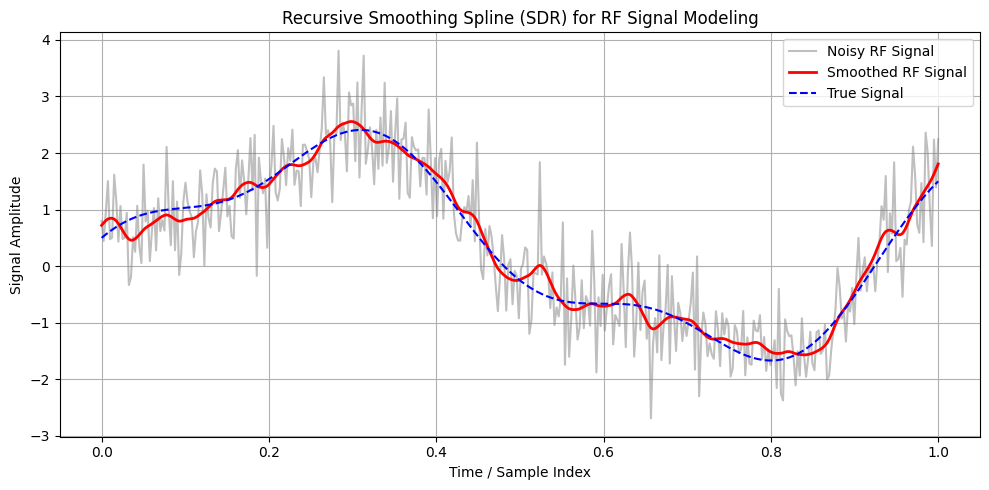

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------
# 1. Generate / Load RF Signal (Demo Data)
# -------------------------------------------------
np.random.seed(42)

N = 400
x = np.linspace(0, 1, N)

# True RF signal (non-linear + oscillatory)
true_signal = (
    2 * np.sin(2 * np.pi * x)
    + 0.5 * np.cos(6 * np.pi * x)
    + x**2
)

# Add noise (simulating RF noise)
noise = np.random.normal(0, 0.6, N)
observed_signal = true_signal + noise

# -------------------------------------------------
# 2. Normalize (Recommended for RF data)
# -------------------------------------------------
scaler = StandardScaler()
z = scaler.fit_transform(observed_signal.reshape(-1, 1)).flatten()

# -------------------------------------------------
# 3. SDR State-Space Model (IRW = Cubic Spline)
# -------------------------------------------------
# State: [signal, slope]
A = np.array([[1, 1],
              [0, 1]])

H = np.array([[1, 0]])

# Noise Variance Ratio (controls smoothness)
process_variance = 0.01
measurement_variance = 1.0

Q = process_variance * np.array([[0, 0],
                                 [0, 1]])

R = np.array([[measurement_variance]])

# -------------------------------------------------
# 4. Kalman Filter (Forward Pass)
# -------------------------------------------------
x_state = np.zeros((2, 1))
P = np.eye(2)

x_filt = np.zeros((N, 2))
P_filt = np.zeros((N, 2, 2))
x_pred = np.zeros((N, 2))
P_pred = np.zeros((N, 2, 2))

for k in range(N):
    # Prediction
    x_state = A @ x_state
    P = A @ P @ A.T + Q

    x_pred[k] = x_state.flatten()
    P_pred[k] = P

    # Update
    y = z[k]
    S = H @ P @ H.T + R
    K = P @ H.T @ np.linalg.inv(S)

    innovation = y - (H @ x_state)[0]
    x_state = x_state + K * innovation
    P = (np.eye(2) - K @ H) @ P

    x_filt[k] = x_state.flatten()
    P_filt[k] = P

# -------------------------------------------------
# 5. Fixed Interval Smoothing (Backward Pass)
# -------------------------------------------------
x_smooth = np.zeros_like(x_filt)
x_smooth[-1] = x_filt[-1]

for k in range(N - 2, -1, -1):
    C = P_filt[k] @ A.T @ np.linalg.inv(P_pred[k + 1])
    x_smooth[k] = x_filt[k] + C @ (x_smooth[k + 1] - x_pred[k + 1])

smoothed_signal = scaler.inverse_transform(
    x_smooth[:, 0].reshape(-1, 1)
).flatten()

# -------------------------------------------------
# 6. Performance Evaluation
# -------------------------------------------------
mse_noisy = mean_squared_error(true_signal, observed_signal)
mse_smoothed = mean_squared_error(true_signal, smoothed_signal)

print("MSE (Noisy Signal):   ", round(mse_noisy, 4))
print("MSE (Smoothed Signal):", round(mse_smoothed, 4))

# -------------------------------------------------
# 7. Visualization
# -------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, observed_signal, color="gray", alpha=0.5, label="Noisy RF Signal")
plt.plot(x, smoothed_signal, color="red", linewidth=2, label="Smoothed RF Signal")
plt.plot(x, true_signal, color="blue", linestyle="--", label="True Signal")
plt.xlabel("Time / Sample Index")
plt.ylabel("Signal Amplitude")
plt.title("Recursive Smoothing Spline (SDR) for RF Signal Modeling")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
